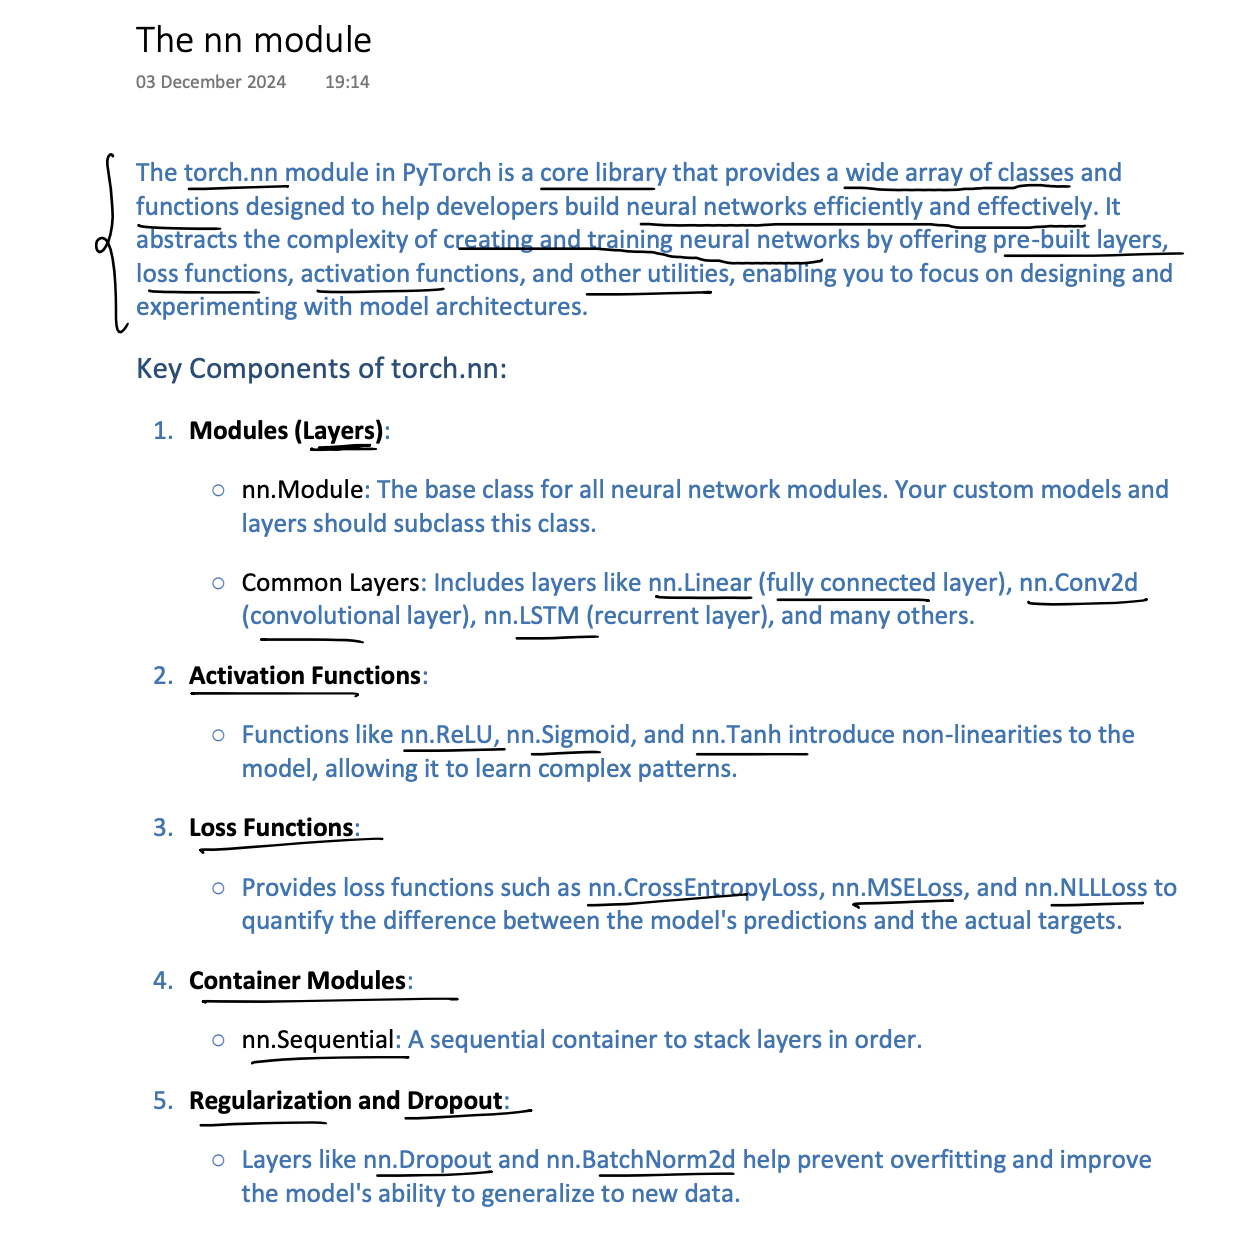

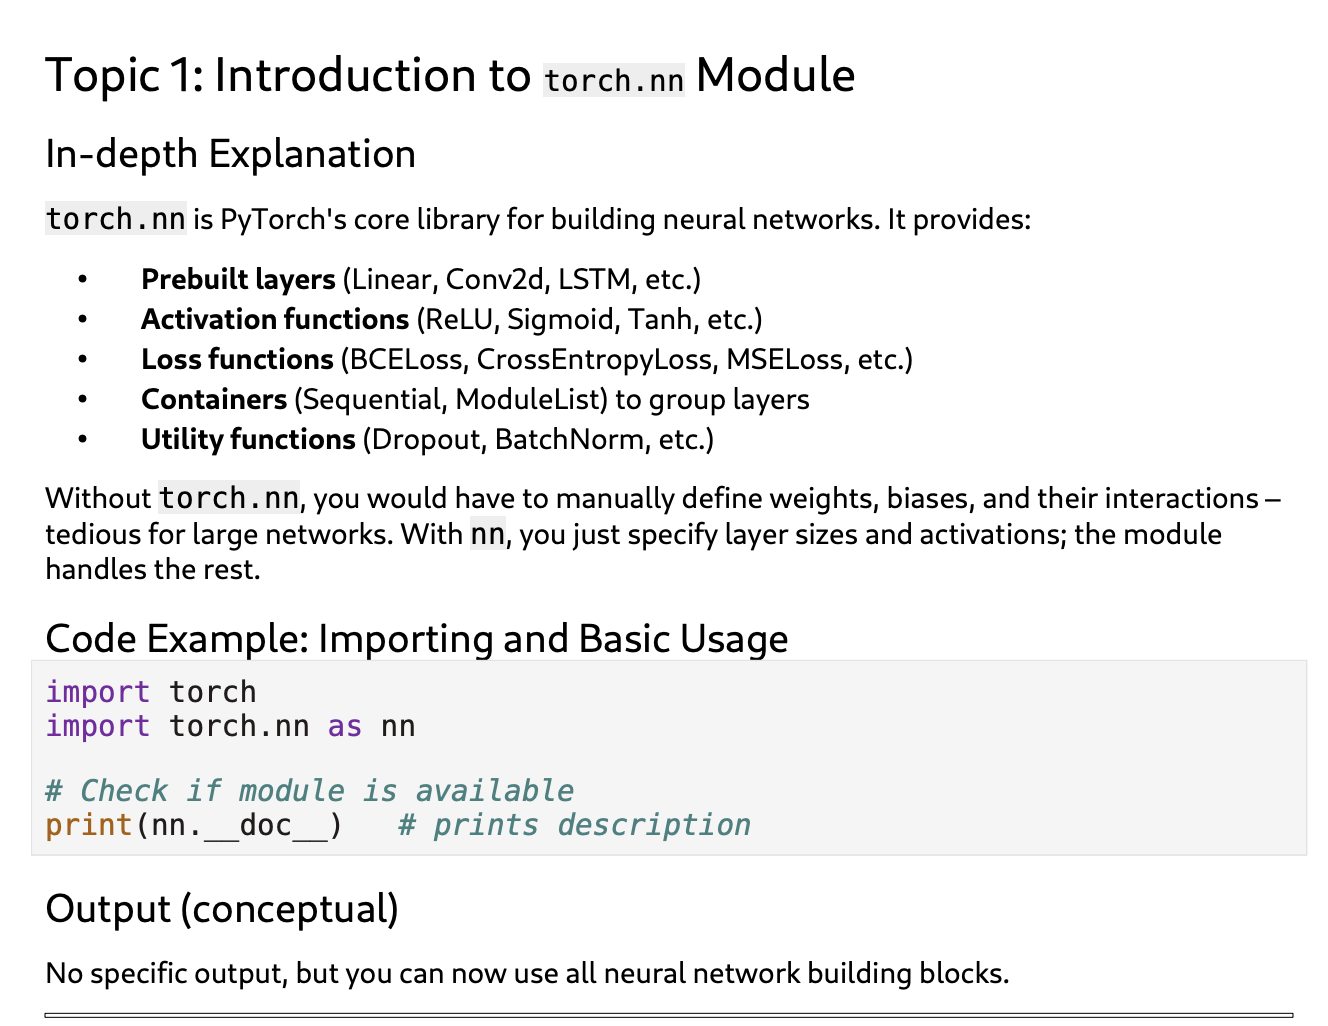

In [1]:
import torch
import torch.nn as nn

#check if module is available
print(nn.__doc__)#print description

None


## Topic 2: Creating a Neural Network with nn.Module (Single Neuron)
In-depth Explanation
- To create a custom model, you inherit from nn.Module. Inside __init__, you define layers as
class attributes. Inside forward, you define how data passes through layers.
Key steps:
1. class MyModel(nn.Module):
2. Call super().__init__() inside __init__ (invokes parent constructor)
3. Define layers: self.linear = nn.Linear(input_size, output_size)
4. Define activation: self.sigmoid = nn.Sigmoid()
5. In forward(self, x): pass x through layers sequentially and return output

Why super().__init__()? It registers all parameters so PyTorch can track gradients and
manage them.

### Code Example: Single Neuron (5 inputs → 1 output with Sigmoid) Forward Pass only (no backward,error calculation and so on) For conceptual Only

In [2]:
#create model class
import torch
import torch.nn as nn

class SingleNeuron(nn.Module):
    def __init__(self,num_features):
        super().__init__() #must call parent constructor
        self.linear=nn.Linear(num_features,1) #Linear layer:Wx+b
        self.sigmoid=nn.Sigmoid() #Activation
    
    def forward(self,x):
        out=self.linear(x) #compute z=Wx+b
        out=self.sigmoid(out) #apply sigmoid
        return out



In [4]:
# Create fake dataset: 10 samples, 5 features each
features=torch.randn(size=(10,5))
print(features.shape)

torch.Size([10, 5])


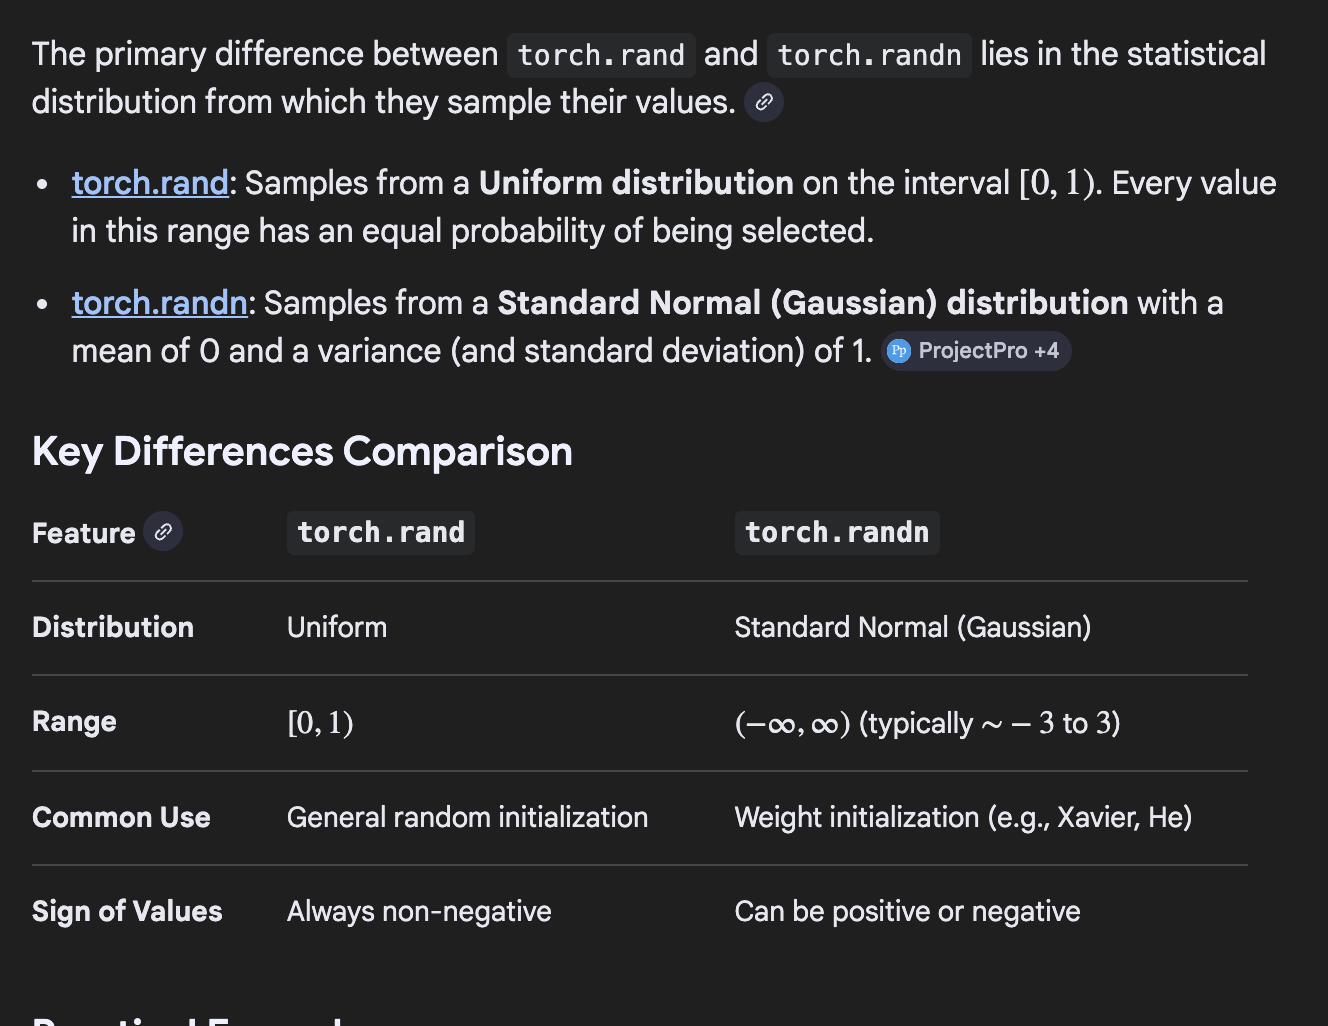

In [6]:
# Instantiate model
model=SingleNeuron(num_features=features.shape[1])

#Forward pass
output=model(features) #Note:Call model directly ,not model.forward(features) though this works ,the model(features) is recommended by pytorch,they somehow have made this __call__ feature trigger forward class if called model .
print("Output shape: ",output.shape)
print("Output: ",output)

Output shape:  torch.Size([10, 1])
Output:  tensor([[0.5984],
        [0.5000],
        [0.2765],
        [0.5218],
        [0.1058],
        [0.5236],
        [0.6117],
        [0.3312],
        [0.3006],
        [0.3267]], grad_fn=<SigmoidBackward0>)


#### Each of the 10 samples gives a single probability value (between 0 and 1).

#### Inspecting Parameters

In [ ]:
#View weights (shape:1*5) 5 features as weights
print("Weights: ",model.linear.weight)

#View bias (shape:1)
print("Bias: ",model.linear.bias)

Weights:  Parameter containing:
tensor([[ 0.1922,  0.3394,  0.1058, -0.1929, -0.3834]], requires_grad=True)
Bias:  Parameter containing:
tensor([-0.3281], requires_grad=True)


Total trainable parameters = 5 weights + 1 bias = 6.

#### Visualizing Network Structure (optional)


In [ ]:
# !pip install torchinfo

In [8]:
from torchinfo import summary

summary(model=model,input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
SingleNeuron                             [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## Topic 3: Adding a Hidden Layer (Multi-Layer Network)

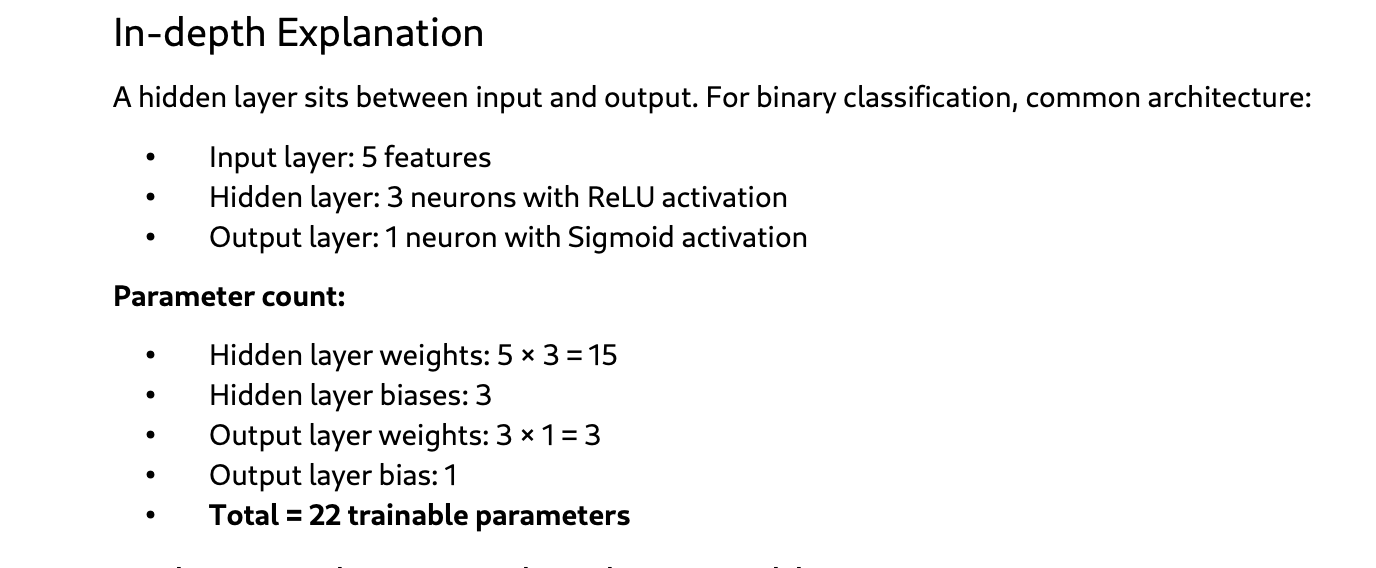

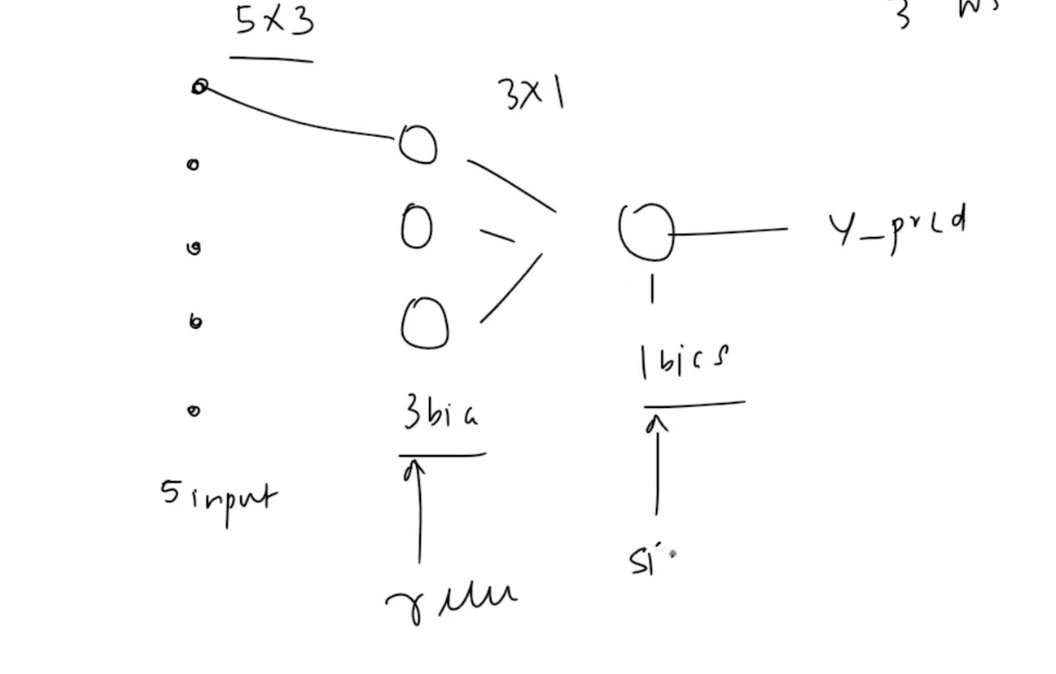

### Code Example: Network with One Hidden Layer

In [9]:
import torch
import torch.nn as nn

In [ ]:
## define class for the model
class TwoLayerNet(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.hidden=nn.Linear(num_features,3) #hidden layer:5 ->3, #linear1
        self.relu=nn.ReLU() #activation for hidden
        self.output=nn.Linear(3,1) #output layer :3 ->1,
        #linear2
        self.sigmoid=nn.Sigmoid() #activation for output

    def forward(self,x):  # x->features
        x=self.hidden(x)
        x=self.relu(x)
        x=self.output(x)
        x=self.sigmoid(x)
        return x

In [ ]:
# Create fake dataset: 10 samples, 5 features each
features=torch.randn(size=(10,5))

# Instantiate the model
model=TwoLayerNet(num_features=features.shape[1])

#call model for forward pass
#model.forward(features)
output=model(features) #features shape:(10,5)

print("Output shape: ",output.shape)
print("Output: ",output)

Output shape:  torch.Size([10, 1])
Output:  tensor([[0.6038],
        [0.5991],
        [0.5971],
        [0.5973],
        [0.5964],
        [0.5738],
        [0.5833],
        [0.5924],
        [0.5698],
        [0.5925]], grad_fn=<SigmoidBackward0>)


#### Inspecting models

In [16]:
#View weights
print("Weights: ",model.hidden.weight)
print("Weights: ",model.output.weight)
#View bias
print("Bias: ",model.hidden.bias)
print("Bias: ",model.output.bias)

Weights:  Parameter containing:
tensor([[-0.2240,  0.2446, -0.1428,  0.2741, -0.4096],
        [ 0.0714,  0.4441, -0.1435, -0.0522,  0.3724],
        [-0.1490, -0.4289, -0.3528, -0.0837,  0.2423]], requires_grad=True)
Weights:  Parameter containing:
tensor([[-0.2212,  0.1271,  0.0617]], requires_grad=True)
Bias:  Parameter containing:
tensor([ 0.2029,  0.0287, -0.4337], requires_grad=True)
Bias:  Parameter containing:
tensor([0.3346], requires_grad=True)


#### Visualizing Network Structure (optional)


In [17]:
from torchinfo import summary

summary(model=model,input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
TwoLayerNet                              [10, 1]                   --
├─Linear: 1-1                            [10, 3]                   18
├─ReLU: 1-2                              [10, 3]                   --
├─Linear: 1-3                            [10, 1]                   4
├─Sigmoid: 1-4                           [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## Topic 4: Using nn.Sequential Container

Writing **forward** manually becomes cumbersome for deep networks. **nn.Sequential** is a
container that automatically chains layers. You pass layers in order, and forward calls them
sequentially.
Benefits:
- Less boilerplate code
- Easy to read architecture
- Still inherits from nn.Module

#### Code Example: Same Two-Layer Net with Sequential

In [ ]:
import torch
import torch.nn as nn
# define class model

class TwoLayerNetSequential(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(num_features,3),
            nn.ReLU(),
            nn.Linear(3,1),
            nn.Sigmoid()
        )
    
    def forward(self,features): 
        out= self.network(features)
        return out #just one line !


In [20]:
# Create fake dataset: 10 samples, 5 features each
features=torch.randn(size=(10,5))

# Instantiate the model
model=TwoLayerNetSequential(num_features=features.shape[1])

#call model for forward pass
#model.forward(features)
output=model(features) #features shape:(10,5)

print("Output shape: ",output.shape)
print("Output: ",output)

Output shape:  torch.Size([10, 1])
Output:  tensor([[0.4547],
        [0.5070],
        [0.3449],
        [0.5475],
        [0.5151],
        [0.5599],
        [0.4739],
        [0.5599],
        [0.4914],
        [0.2083]], grad_fn=<SigmoidBackward0>)


## Topic 5: Using Built-in Loss Function (BCELoss)

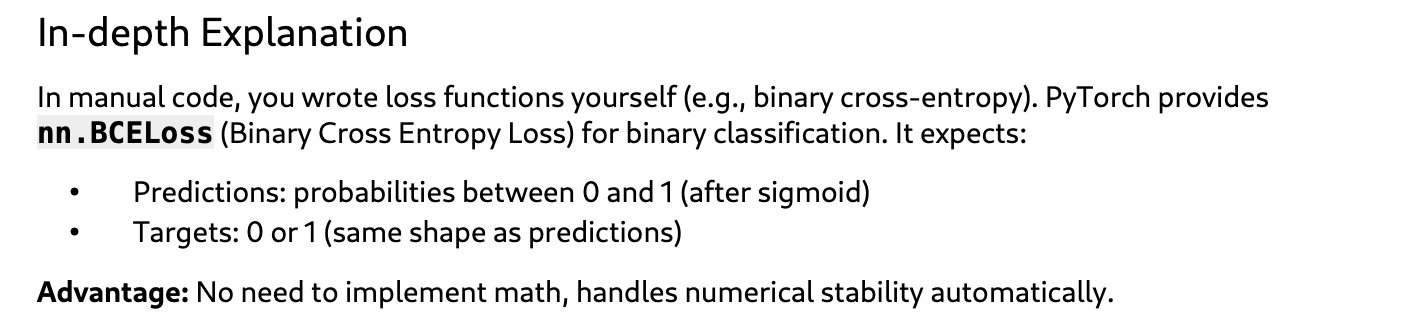

#### Code Example: Replacing Manual Loss with BCELoss

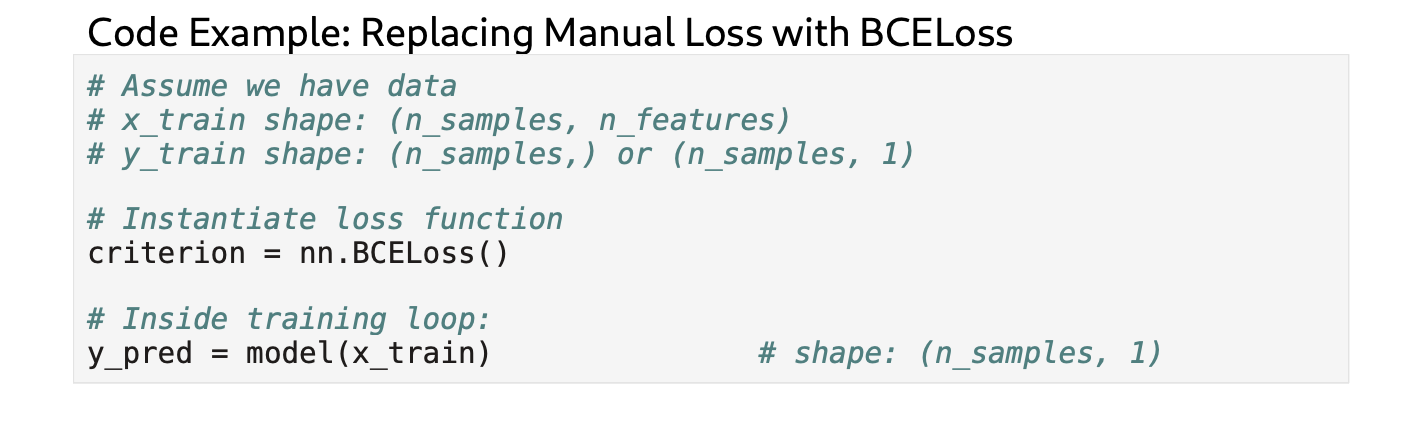

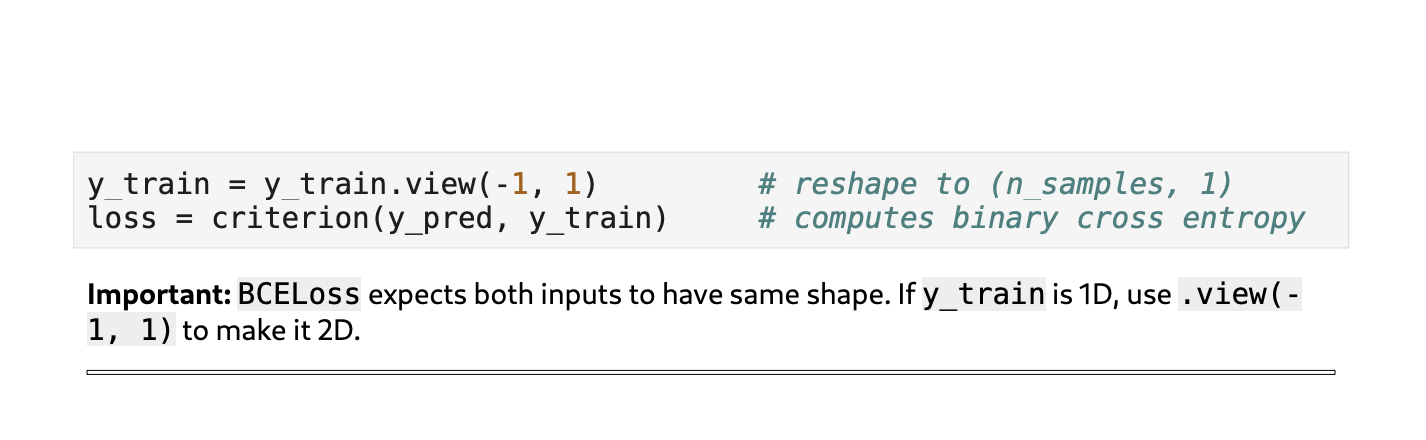

`view()` in PyTorch reshapes a tensor without changing its data.

In your code:

```python
y_train_reshaped = y_train.view(-1, 1)
```

the goal is to make `y_train` have the same shape as `y_pred`.

For example:

```python
print(y_train.shape)
```

might give:

```python
torch.Size([100])
```

That means it's a 1D tensor with 100 values.

But your model output (`y_pred`) is often shaped like:

```python
torch.Size([100, 1])
```

which is a 2D tensor: 100 rows and 1 column.

Loss functions like `nn.MSELoss()` expect both tensors to have the same shape, so we reshape `y_train`.

---

### What `view(-1, 1)` means

```python
.view(rows, columns)
```

* `1` means: make 1 column
* `-1` means: PyTorch automatically figures out the correct number of rows

So:

```python
y_train.view(-1, 1)
```

turns this:

```python
tensor([1, 2, 3, 4])
```

shape:

```python
[4]
```

into:

```python
tensor([[1],
        [2],
        [3],
        [4]])
```

shape:

```python
[4, 1]
```

---

Here’s a small visualization:

Before:

y_train \in \mathbb{R}^{4}

After `view(-1,1)`:

y_train \in \mathbb{R}^{4 \times 1}

---

Your full code should probably be:

```python
for epoch in range(epochs):
    # Forward pass
    y_pred = model(x_train)

    # reshape target
    y_train_reshaped = y_train.view(-1, 1)

    # compute loss
    loss = criterion(y_pred, y_train_reshaped)
```

You also had a typo here:

```python
loss = criterion(y_p
```

It should be:

```python
loss = criterion(y_pred, y_train_reshaped)
```


## Topic 6: Using Built-in Optimizer (torch.optim)

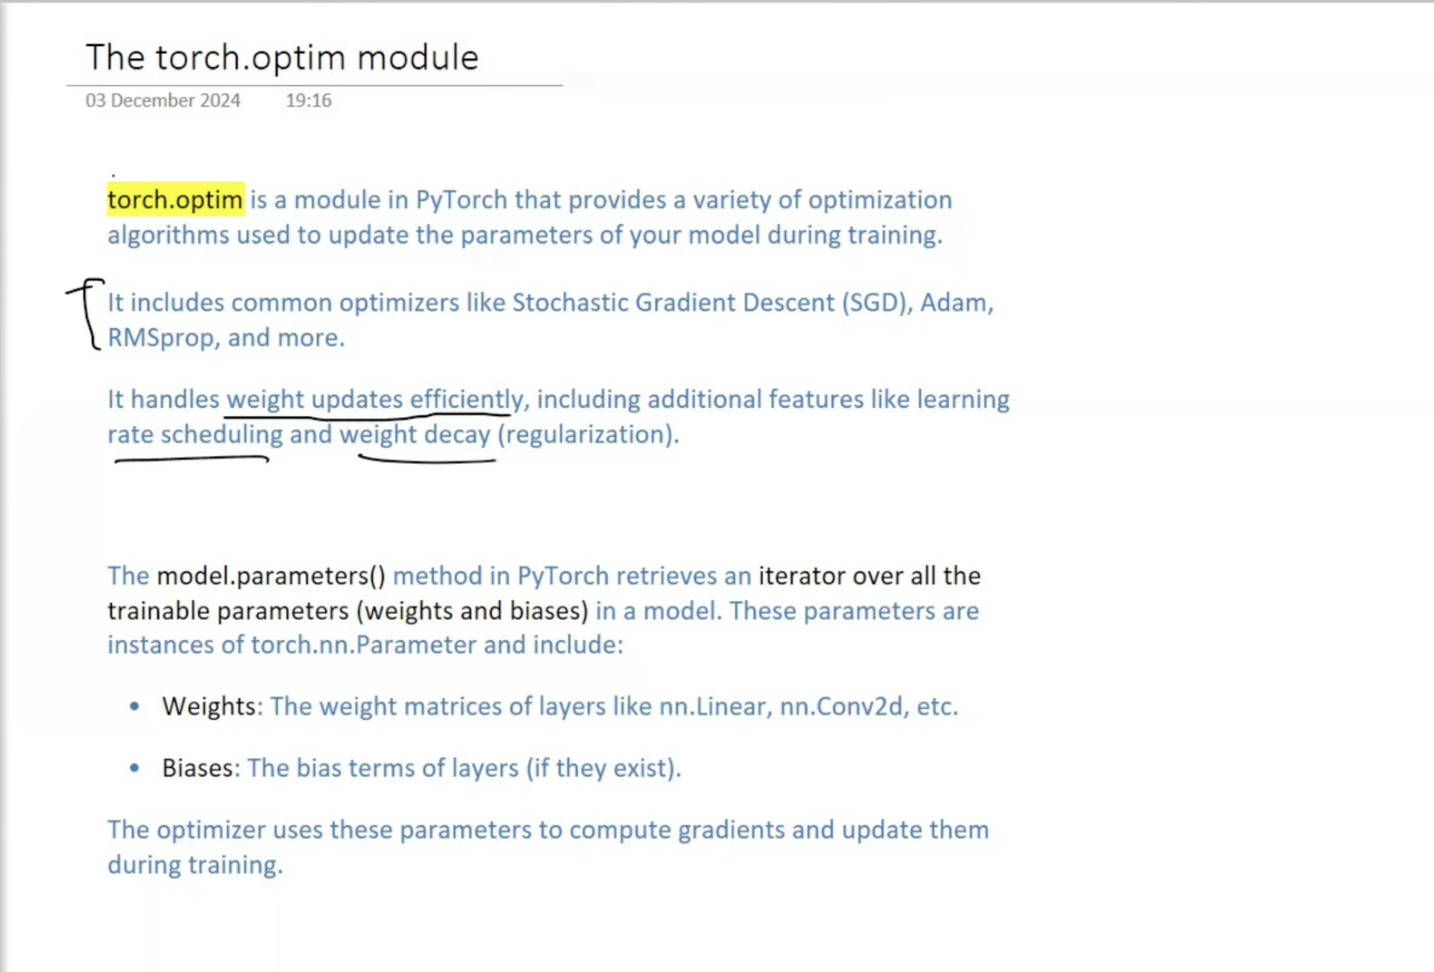

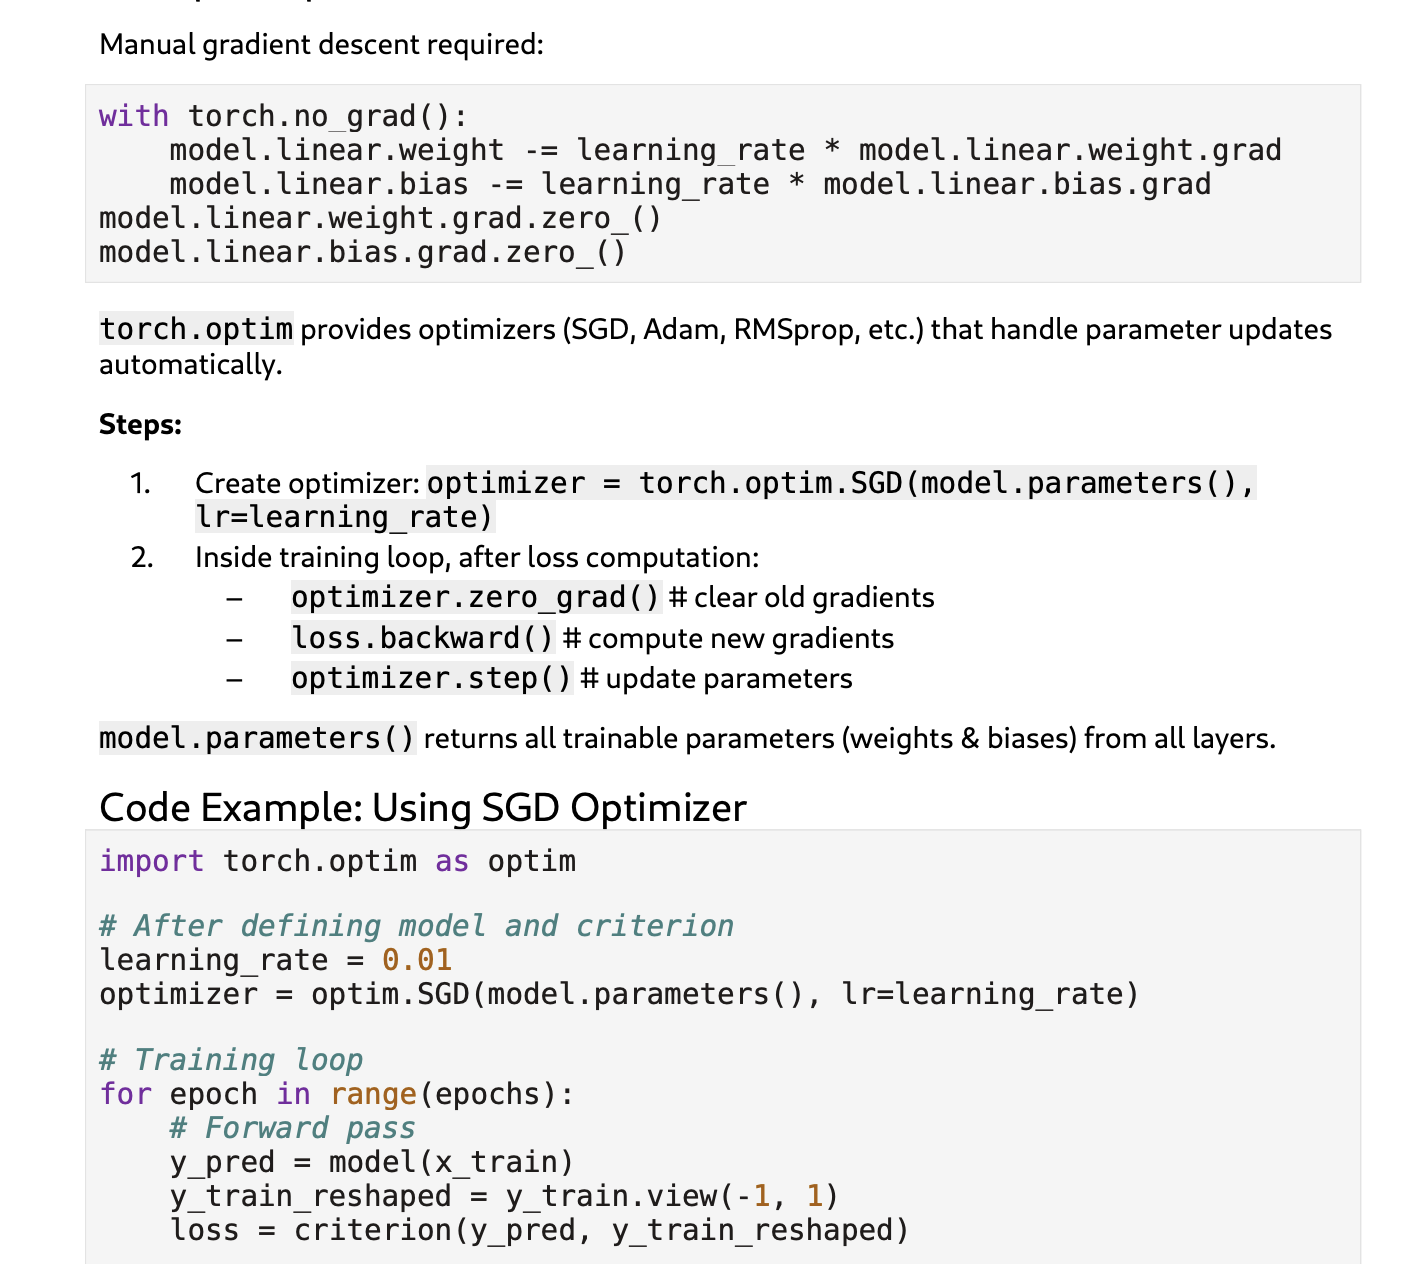

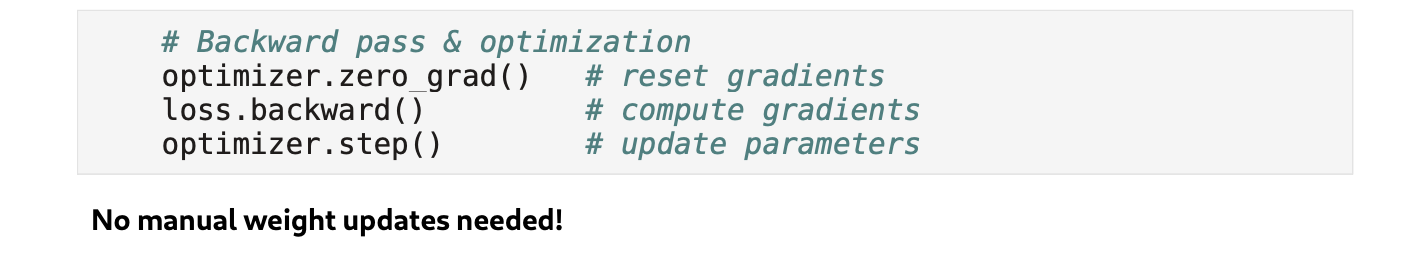

## Complete Improved Training Pipeline (All Four Improvements)

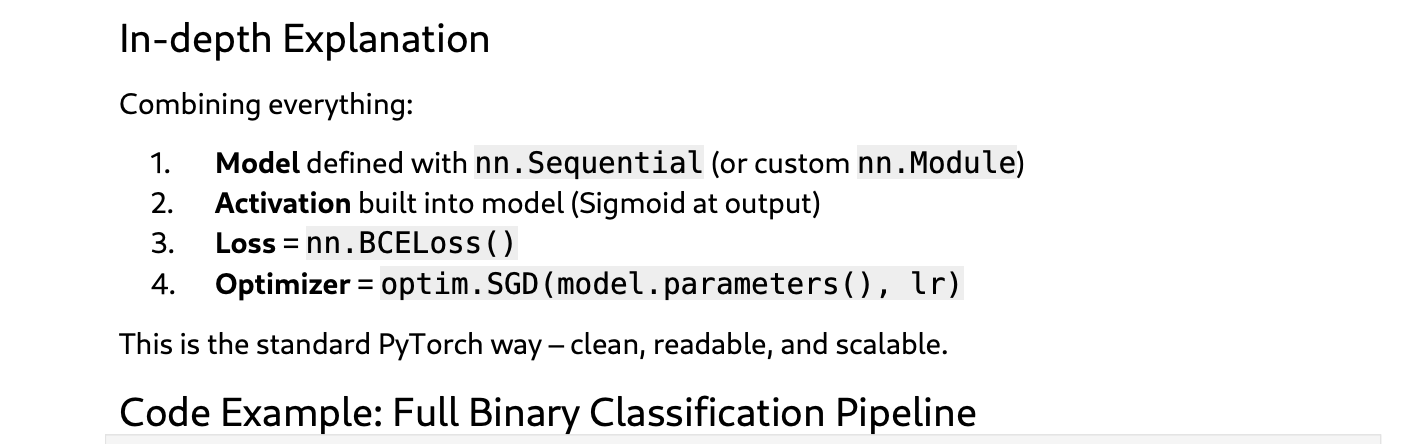

### Dont run this code (just for complete pipeline example)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
# ---------- 1. Load & preprocess data (example) ----------
# Assume x_train, y_train are already tensors
# x_train shape: (n_samples, n_features)
# y_train shape: (n_samples,) with values 0/1
n_features = x_train.shape[1]
# ---------- 2. Define Model ----------
model = nn.Sequential(
 nn.Linear(n_features, 3),
 nn.ReLU(),
 nn.Linear(3, 1),
 nn.Sigmoid()
)
# ---------- 3. Define Loss ----------
criterion = nn.BCELoss()
# ---------- 4. Define Optimizer ----------
learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
# ---------- 5. Training Loop ----------
epochs = 100
for epoch in range(epochs):
 # Forward pass
 y_pred = model(x_train)
 y_train_reshaped = y_train.view(-1, 1) # ensure same shape
 loss = criterion(y_pred, y_train_reshaped)

 # Backward pass & optimization
 optimizer.zero_grad()
 loss.backward()
 optimizer.step()

 # Optional: print loss every 10 epochs
 if (epoch+1) % 10 == 0:
 print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
# ---------- 6. Evaluation ----------
with torch.no_grad():
 y_pred_final = model(x_train)
 predicted = (y_pred_final > 0.5).float()
 accuracy = (predicted.view(-1) == y_train).float().mean()
 print(f"Accuracy: {accuracy.item():.4f}")


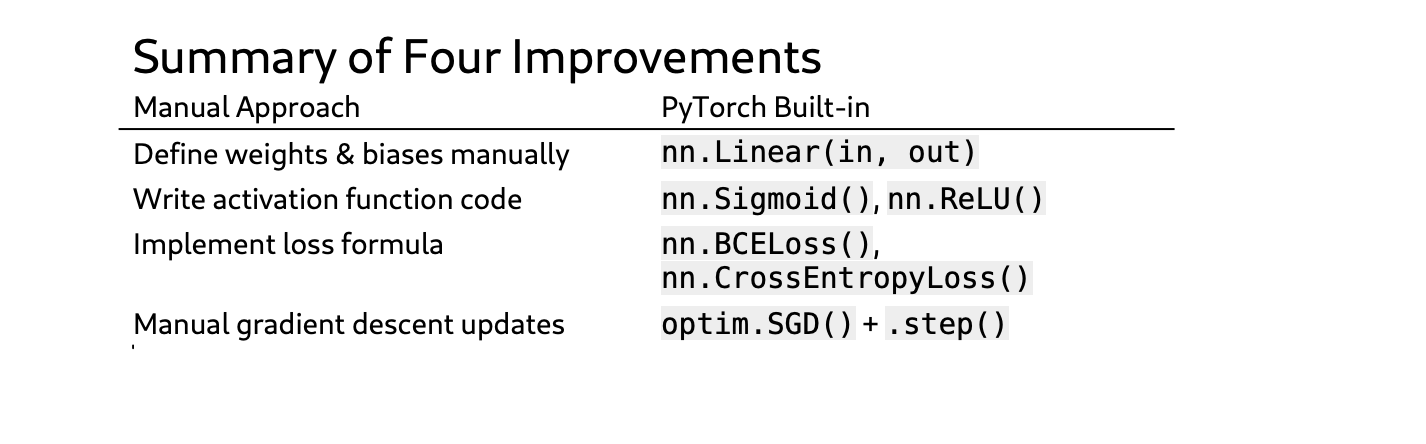

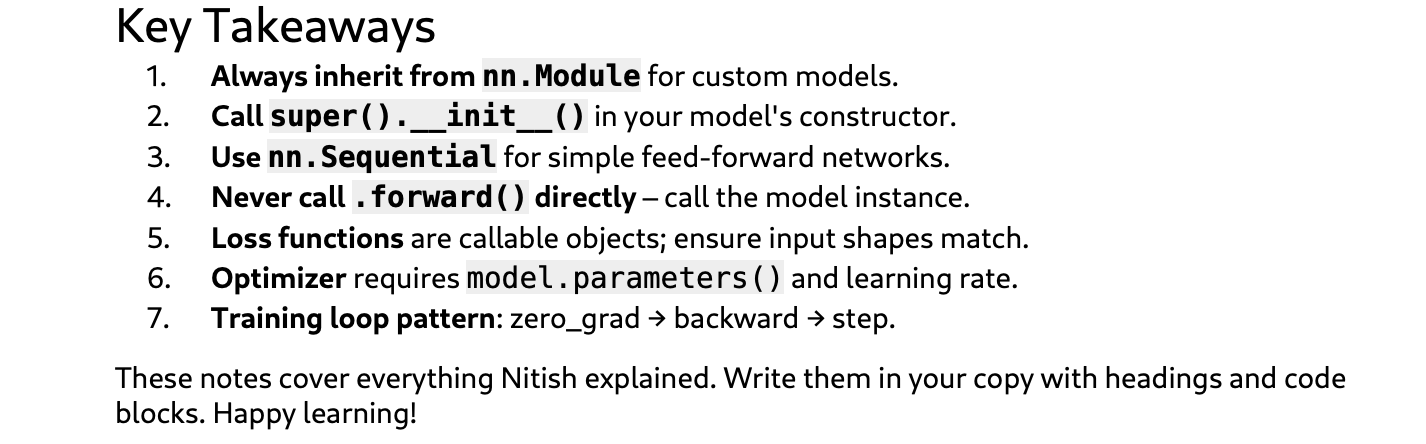

## The ultimate complete flow


In [ ]:
# =============================================================================
# COMPLETE ML PIPELINE: Data Cleaning → Preprocessing → Training → Evaluation
# =============================================================================
# Tools used:
#   - pandas  : Load and clean raw data
#   - numpy   : Numerical operations
#   - sklearn : Preprocessing, splitting, evaluation metrics
#   - pytorch : Neural network, training loop, inference
#
# Pipeline Steps:
#   1.  Load raw data (CSV or synthetic)
#   2.  Inspect & clean data (handle missing values, duplicates)
#   3.  Feature engineering (encode categoricals, drop useless cols)
#   4.  Split data  →  Train / Validation / Test
#   5.  Scale features (StandardScaler)
#   6.  Convert to PyTorch tensors
#   7.  Build Dataset & DataLoader (mini-batch training)
#   8.  Define Neural Network (nn.Sequential — best scalable method)
#   9.  Define Loss & Optimizer
#   10. Training loop (with validation tracking)
#   11. Evaluate on test set
#   12. Inference / prediction helper
#   13. Save & load model checkpoint
# =============================================================================


# ── 0. IMPORTS ────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Reproducibility: fix random seeds everywhere
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


# =============================================================================
# STEP 1 — LOAD RAW DATA
# =============================================================================
# In a real project you'd do:
#   df = pd.read_csv("your_file.csv")
#
# Here we BUILD a realistic synthetic dataset so you can run this file as-is.
# It mimics a real-world CSV with messy problems (missing values, duplicates,
# a categorical column, and an irrelevant ID column).
# =============================================================================

def create_synthetic_raw_data(n_samples: int = 1000) -> pd.DataFrame:
    """
    Simulate a raw CSV dataset for binary classification.
    Contains intentional issues so we can demonstrate cleaning steps.
    """
    rng = np.random.default_rng(SEED)

    age        = rng.integers(18, 70, n_samples).astype(float)
    income     = rng.normal(50_000, 15_000, n_samples)
    score      = rng.uniform(0, 100, n_samples)
    education  = rng.choice(["High School", "Bachelor", "Master", "PhD"],
                             n_samples)
    record_id  = np.arange(n_samples)                          # useless column

    # Non-linear target: 1 if (normalised age + income + score) > threshold
    z      = (age / 70) + (income / 100_000) + (score / 100)
    label  = (z > 1.2).astype(int)

    df = pd.DataFrame({
        "record_id" : record_id,
        "age"       : age,
        "income"    : income,
        "score"     : score,
        "education" : education,
        "label"     : label,
    })

    # ── Inject artificial problems ──────────────────────────────────────────
    # 5 % missing values in age & income
    missing_idx = rng.choice(n_samples, size=int(0.05 * n_samples), replace=False)
    df.loc[missing_idx, "age"]    = np.nan
    df.loc[missing_idx, "income"] = np.nan

    # 2 % duplicate rows
    dup_idx = rng.choice(n_samples, size=int(0.02 * n_samples), replace=False)
    df = pd.concat([df, df.iloc[dup_idx]], ignore_index=True)

    return df


print("=" * 60)
print("STEP 1 — Loading raw data")
print("=" * 60)

df = create_synthetic_raw_data(n_samples=1000)
print(f"Raw data shape : {df.shape}")
print(df.head())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())


# =============================================================================
# STEP 2 — DATA CLEANING  (pandas)
# =============================================================================

print("\n" + "=" * 60)
print("STEP 2 — Cleaning data")
print("=" * 60)

# ── 2a. Drop duplicate rows ──────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows  →  {len(df)} rows remain")

# ── 2b. Drop irrelevant columns ──────────────────────────────────────────────
df = df.drop(columns=["record_id"])        # ID carries no signal
print("Dropped 'record_id' column")

# ── 2c. Fill missing values ──────────────────────────────────────────────────
# Numerical: fill with column MEDIAN (robust to outliers)
for col in ["age", "income"]:
    median_val = df[col].median()
    n_filled   = df[col].isnull().sum()
    df[col]    = df[col].fillna(median_val)
    print(f"Filled {n_filled} missing '{col}' values with median={median_val:.2f}")

print("\nAfter cleaning:")
print(f"  Shape          : {df.shape}")
print(f"  Missing values : {df.isnull().sum().sum()}")


# =============================================================================
# STEP 3 — FEATURE ENGINEERING  (pandas + sklearn LabelEncoder)
# =============================================================================

print("\n" + "=" * 60)
print("STEP 3 — Feature engineering")
print("=" * 60)

# ── 3a. Encode categorical column ────────────────────────────────────────────
# LabelEncoder converts strings → integers:
#   "Bachelor"→0, "High School"→1, "Master"→2, "PhD"→3  (alphabetical)
le = LabelEncoder()
df["education_enc"] = le.fit_transform(df["education"])
df = df.drop(columns=["education"])        # drop original string column
print("Encoded 'education':", dict(zip(le.classes_, le.transform(le.classes_))))

# ── 3b. Separate features (X) and target (y) ────────────────────────────────
X = df.drop(columns=["label"]).values.astype(np.float32)  # shape (n, 4)
y = df["label"].values.astype(np.float32)                  # shape (n,)
print(f"\nFeatures shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Class balance  : {int(y.sum())} positives / {int(len(y) - y.sum())} negatives")


# =============================================================================
# STEP 4 — TRAIN / VALIDATION / TEST SPLIT  (sklearn)
# =============================================================================

print("\n" + "=" * 60)
print("STEP 4 — Train / Validation / Test split  (70 / 15 / 15)")
print("=" * 60)

# First split: 70 % train, 30 % temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Second split: 50/50 of the 30 % temp → 15 % val, 15 % test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train size      : {X_train.shape[0]}")
print(f"Validation size : {X_val.shape[0]}")
print(f"Test size       : {X_test.shape[0]}")


# =============================================================================
# STEP 5 — FEATURE SCALING  (sklearn StandardScaler)
# =============================================================================
# StandardScaler: for each feature → subtract mean, divide by std
# Result: all features have mean=0, std=1
#
# IMPORTANT RULE:
#   Fit (compute mean/std) ONLY on training data.
#   Transform (apply scaling) on train, val, AND test.
#   This prevents "data leakage" — letting future data influence training.
# =============================================================================

print("\n" + "=" * 60)
print("STEP 5 — Scaling features with StandardScaler")
print("=" * 60)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn + apply
X_val   = scaler.transform(X_val)         # apply only
X_test  = scaler.transform(X_test)        # apply only

print(f"Train features mean (should ≈ 0) : {X_train.mean(axis=0).round(4)}")
print(f"Train features std  (should ≈ 1) : {X_train.std(axis=0).round(4)}")


# =============================================================================
# STEP 6 — CONVERT TO PYTORCH TENSORS
# =============================================================================

print("\n" + "=" * 60)
print("STEP 6 — Converting NumPy arrays → PyTorch tensors")
print("=" * 60)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)

X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

print(f"X_train tensor : {X_train_t.shape}  dtype={X_train_t.dtype}")
print(f"y_train tensor : {y_train_t.shape}  dtype={y_train_t.dtype}")


# =============================================================================
# STEP 7 — CUSTOM DATASET CLASS + DATALOADER
# =============================================================================
# Why DataLoader?
#   Training on ALL data at once (batch gradient descent) is slow for large
#   datasets and can get stuck in bad local minima.
#   DataLoader splits data into mini-batches and shuffles each epoch.
# =============================================================================

print("\n" + "=" * 60)
print("STEP 7 — Building Dataset and DataLoader")
print("=" * 60)


class TabularDataset(Dataset):
    """
    A generic Dataset for tabular (structured) data.
    __len__ : tells DataLoader how many samples exist.
    __getitem__ : returns (features, label) for a given index.
    """
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X = X
        self.y = y

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_loader = DataLoader(
    TabularDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,          # shuffle every epoch → better generalisation
    drop_last=False,
)
val_loader = DataLoader(
    TabularDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    TabularDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"Batch size      : {BATCH_SIZE}")
print(f"Train batches   : {len(train_loader)}")
print(f"Val batches     : {len(val_loader)}")
print(f"Test batches    : {len(test_loader)}")


# =============================================================================
# STEP 8 — DEFINE NEURAL NETWORK  (nn.Sequential — best scalable method)
# =============================================================================
# nn.Sequential is the recommended scalable approach from the notebook.
# It chains layers in order without having to write a manual forward() method.
#
# Architecture:
#   Input(4) → Linear → ReLU → Linear → ReLU → Linear(1) → Sigmoid
#
# Why Sigmoid at the end?
#   Squashes output to (0, 1) → interpret as probability of class 1.
# Why ReLU in hidden layers?
#   Non-linearity that avoids the vanishing-gradient problem.
# =============================================================================

print("\n" + "=" * 60)
print("STEP 8 — Defining Neural Network")
print("=" * 60)

N_FEATURES  = X_train.shape[1]   # 4
HIDDEN_SIZE = 16


class NeuralNet(nn.Module):
    """
    Binary-classification neural net built with nn.Sequential.
    Adding more layers is trivial — just insert them inside Sequential.
    """
    def __init__(self, input_size: int, hidden_size: int = 16):
        super().__init__()          # MUST call parent __init__
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),   # Layer 1: input → hidden
            nn.ReLU(),                             # Activation
            nn.Linear(hidden_size, hidden_size),  # Layer 2: hidden → hidden
            nn.ReLU(),                             # Activation
            nn.Linear(hidden_size, 1),            # Layer 3: hidden → output
            nn.Sigmoid(),                          # Output: probability (0-1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)     # Sequential calls each layer in order


model = NeuralNet(input_size=N_FEATURES, hidden_size=HIDDEN_SIZE)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params}")


# =============================================================================
# STEP 9 — LOSS FUNCTION & OPTIMIZER
# =============================================================================
# BCELoss  : Binary Cross-Entropy — standard loss for binary classification.
#            Penalises confident wrong predictions heavily.
# Adam     : Adaptive learning-rate optimizer — better than plain SGD for most
#            tasks. Combines momentum + per-parameter learning rates.
# =============================================================================

print("\n" + "=" * 60)
print("STEP 9 — Loss and Optimizer")
print("=" * 60)

LEARNING_RATE = 0.001
criterion = nn.BCELoss()                                         # loss fn
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)    # optimizer

print(f"Loss function  : {criterion}")
print(f"Optimizer      : Adam  (lr={LEARNING_RATE})")


# =============================================================================
# STEP 10 — TRAINING LOOP
# =============================================================================
# Every epoch:
#   1. model.train()   — enable dropout / batch-norm training behaviour
#   2. Loop over mini-batches from train_loader
#      a. Forward pass  : y_pred = model(X_batch)
#      b. Compute loss  : loss = criterion(y_pred, y_true)
#      c. Zero grads    : optimizer.zero_grad()  ← MUST do before backward
#      d. Backward pass : loss.backward()        ← compute gradients
#      e. Update weights: optimizer.step()       ← apply gradients
#   3. model.eval() + torch.no_grad()  — validation without updating weights
# =============================================================================

def train_one_epoch(model, loader, criterion, optimizer):
    """Run one full pass over the training data."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        # ── Forward pass ─────────────────────────────────────────────────────
        y_pred = model(X_batch).squeeze()          # shape: (batch,)
        loss   = criterion(y_pred, y_batch)

        # ── Backward pass ─────────────────────────────────────────────────────
        optimizer.zero_grad()                      # clear old gradients
        loss.backward()                            # compute new gradients
        optimizer.step()                           # update model weights

        # ── Metrics ───────────────────────────────────────────────────────────
        total_loss += loss.item()
        predicted   = (y_pred > 0.5).float()
        correct    += (predicted == y_batch).sum().item()
        total      += y_batch.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    """Evaluate model on any DataLoader without updating weights."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():                          # no gradient computation
        for X_batch, y_batch in loader:
            y_pred     = model(X_batch).squeeze()
            loss       = criterion(y_pred, y_batch)

            total_loss += loss.item()
            predicted   = (y_pred > 0.5).float()
            correct    += (predicted == y_batch).sum().item()
            total      += y_batch.size(0)

    return total_loss / len(loader), correct / total


print("\n" + "=" * 60)
print("STEP 10 — Training")
print("=" * 60)

EPOCHS = 50
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS} | "
              f"Train Loss={tr_loss:.4f} Acc={tr_acc:.4f} | "
              f"Val   Loss={vl_loss:.4f} Acc={vl_acc:.4f}")

print("\nTraining complete!")


# =============================================================================
# STEP 11 — EVALUATION ON TEST SET
# =============================================================================

print("\n" + "=" * 60)
print("STEP 11 — Test Set Evaluation")
print("=" * 60)

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

# Detailed sklearn classification report (precision, recall, F1)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs   = model(X_batch).squeeze()
        preds   = (probs > 0.5).float()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Class 0", "Class 1"]))


# =============================================================================
# STEP 12 — INFERENCE / PREDICTION HELPER
# =============================================================================
# Use this function to predict on NEW, unseen data after training.
# =============================================================================

def predict(model, X_new: np.ndarray, scaler: StandardScaler):
    """
    Make predictions on raw (unscaled) numpy data.

    Parameters
    ----------
    model   : trained NeuralNet
    X_new   : numpy array of shape (n_samples, n_features)  — RAW, unscaled
    scaler  : the SAME StandardScaler fitted on training data

    Returns
    -------
    predictions  : np.ndarray of ints (0 or 1)
    probabilities: np.ndarray of floats in [0, 1]
    """
    model.eval()

    # Scale exactly the same way as training data
    X_scaled = scaler.transform(X_new).astype(np.float32)
    X_tensor = torch.tensor(X_scaled)

    with torch.no_grad():
        probs = model(X_tensor).squeeze().numpy()

    preds = (probs > 0.5).astype(int)
    return preds, probs


print("\n" + "=" * 60)
print("STEP 12 — Inference on 3 new samples")
print("=" * 60)

# Simulate 3 brand-new raw samples (age, income, score, education_enc)
new_raw = np.array([
    [25, 45_000, 70, 1],   # Bachelor
    [55, 90_000, 85, 2],   # Master
    [40, 30_000, 40, 0],   # High School
], dtype=np.float32)

preds, probs = predict(model, new_raw, scaler)
for i, (p, prob) in enumerate(zip(preds, probs)):
    print(f"  Sample {i+1}: Predicted class={p}  (probability={prob:.4f})")


# =============================================================================
# STEP 13 — SAVE & LOAD MODEL CHECKPOINT
# =============================================================================
# Save BOTH model weights AND optimizer state → lets you resume training later.
# =============================================================================

print("\n" + "=" * 60)
print("STEP 13 — Save & Load Model")
print("=" * 60)

CHECKPOINT_PATH = "model_checkpoint.pth"

torch.save({
    "model_state_dict"     : model.state_dict(),
    "optimizer_state_dict" : optimizer.state_dict(),
    "model_config"         : {"input_size": N_FEATURES, "hidden_size": HIDDEN_SIZE},
    "test_accuracy"        : test_acc,
    "epochs_trained"       : EPOCHS,
}, CHECKPOINT_PATH)
print(f"Model saved  → '{CHECKPOINT_PATH}'")


def load_model(path: str) -> NeuralNet:
    """Load a saved model checkpoint."""
    checkpoint  = torch.load(path, weights_only=True)
    cfg         = checkpoint["model_config"]
    loaded_mdl  = NeuralNet(input_size=cfg["input_size"],
                             hidden_size=cfg["hidden_size"])
    loaded_mdl.load_state_dict(checkpoint["model_state_dict"])
    loaded_mdl.eval()
    print(f"Model loaded ← '{path}'")
    print(f"  Saved test accuracy : {checkpoint['test_accuracy']:.4f}")
    return loaded_mdl


loaded_model = load_model(CHECKPOINT_PATH)


# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
print(f"  Dataset        : {len(df)} samples, {N_FEATURES} features")
print(f"  Train / Val / Test : {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"  Model          : NeuralNet  ({total_params} params)")
print(f"  Optimizer      : Adam  lr={LEARNING_RATE}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Final Test Acc : {test_acc:.4f}")
print("=" * 60)